# Analyse exploratoire

In [41]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns


Distribution des classes : le corpus est-il équilibré ?

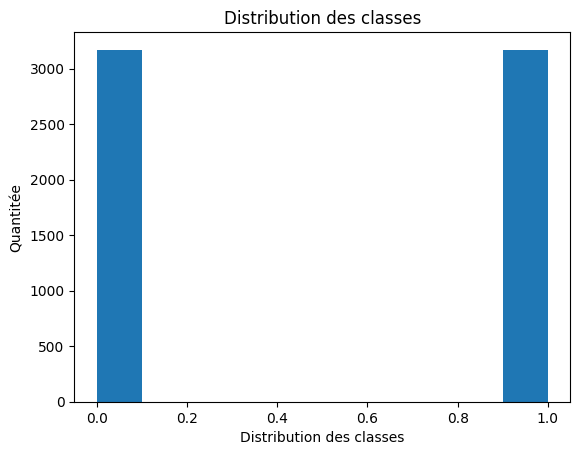

In [42]:
df = pd.read_csv("../data/titles_clean.csv")

plt.figure()
plt.hist(df["label"], bins=10)
plt.xlabel("Distribution des classes")
plt.ylabel("Quantitée")
plt.title("Distribution des classes")
plt.savefig("../figures/distribution_classes", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

Distribution de la longueur des titres en tokens

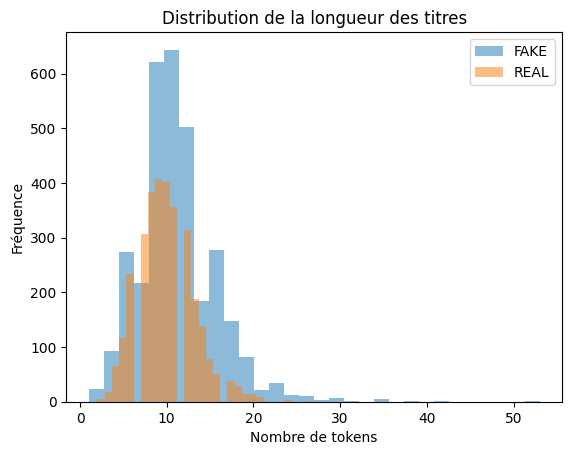

In [43]:
df["length"] = df["text"].apply(lambda x: len(str(x).split()))

fake = df[df["label"] == 0]["length"]
real = df[df["label"] == 1]["length"]

plt.figure()
plt.hist(fake, bins=30, alpha=0.5, label="FAKE")
plt.hist(real, bins=30, alpha=0.5, label="REAL")

plt.xlabel("Nombre de tokens")
plt.ylabel("Fréquence")
plt.title("Distribution de la longueur des titres")
plt.legend()

plt.show()

Top 20 des tokens les plus fréquents dans chaque classe — affichez deux diagrammes en barres côte à côte

Approche : 

    - Récupérer la liste des tokens (mots) dans chaque titre

    - Faire la somme des tokens pour chaque classe

    - Récupérer le top 20 des tokens les plus fréquents dans les 2 classes
    
    - Créer le diagramme en barre

0                      [you, can, smell, hillary’s, fear]
1       [watch, the, exact, moment, paul, ryan, commit...
2       [kerry, to, go, to, paris, in, gesture, of, sy...
3       [bernie, supporters, on, twitter, erupt, in, a...
4       [the, battle, of, new, york:, why, this, prima...
                              ...                        
6330    [state, department, says, it, can't, find, ema...
6331    [the, ‘p’, in, pbs, should, stand, for, ‘pluto...
6332    [anti-trump, protesters, are, tools, of, the, ...
6333    [in, ethiopia,, obama, seeks, progress, on, pe...
6334    [jeb, bush, is, suddenly, attacking, trump., h...
Name: tokens, Length: 6335, dtype: object
Top 20 des mots les plus fréquents dans les fakes news : [('the', 1137), ('to', 898), ('of', 642), ('in', 556), ('for', 413), ('on', 404), ('and', 372), ('trump', 360), ('a', 353), ('is', 346), ('hillary', 326), ('clinton', 265), ('by', 218), ('with', 181), ('–', 171), ('-', 161), ('from', 149), ('election', 141), ('ne

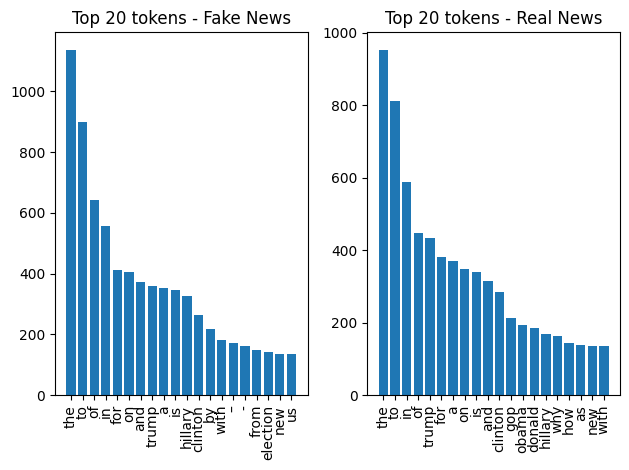

In [45]:
df["tokens"] = df["text"].apply(lambda x: str(x).lower().split()) 

print(df["tokens"])

fake_news_tokens_sum = df[df["label"] == 0]["tokens"].sum()
real_new_tokens_sum = df[df["label"] == 1]["tokens"].sum()

fake_news_counts = Counter(fake_news_tokens_sum).most_common(20)
real_news_counts = Counter(real_new_tokens_sum).most_common(20)

print(f"Top 20 des mots les plus fréquents dans les fakes news : {fake_news_counts}")
print(f"Top 20 des mots les plus fréquents dans les news : {real_news_counts}")

fake_news_token, fake_news_counter = zip(*fake_news_counts)
real_new_token, real_news_counter = zip(*real_news_counts)

print(fake_news_counter)
print(real_news_counter)

fig, axes = plt.subplots(1, 2)

axes[0].bar(fake_news_token, fake_news_counter)
axes[0].set_title("Top 20 tokens - Fake News")
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(real_new_token, real_news_counter)
axes[1].set_title("Top 20 tokens - Real News")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Identification des tokens présents dans une seule classe (discriminants purs) : listez les 10 premiers par classe

Identifiez au moins 3 titres potentiellement ambigus (ni clairement fiables, ni clairement trompeurs) et expliquez pourquoi ils posent problème